# Описание проекта. Сборный проект №3

Вы — специалист по Data Science в каршеринговой компании. Вам поступил заказ: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.

Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует. Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

Идея решения задачи от заказчика: 
1. Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
	- Для модели выбрать тип виновника — только машина (car).
	- Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
	- Для моделирования ограничиться данными за 2012 год — они самые свежие.
	- Обязательное условие — учесть фактор возраста автомобиля.

2. На основе модели исследовать основные факторы ДТП.
3. Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
	- Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
	- Какие ещё факторы нужно учесть?
	- Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?
4. Заказчик предлагает вам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы. 

### Загрузка библиотек

In [2]:
!pip install category_encoders -q

In [3]:
!pip install torch -q

In [4]:
!pip install phik -q

In [5]:
!pip install -U scikit-learn -q

In [6]:
!pip install imblearn -q

In [7]:
!pip install optuna -q

In [8]:
!pip install optuna-integration -q

In [9]:
!pip install psycopg2-binary -q

In [10]:
!pip install catboost -q

In [ ]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import psycopg2
from psycopg2.extras import RealDictCursor

import phik

from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, root_mean_squared_error, \
							precision_score, recall_score, \
                            confusion_matrix, roc_curve, auc, classification_report, \
                            precision_recall_curve, average_precision_score


from math import ceil

from numpy.random import RandomState
from numpy import mean
from numpy import std

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import optuna
from optuna_integration import CatBoostPruningCallback
from catboost import Pool, cv
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import f_classif

# загружаем класс pipeline
from imblearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier, Pool, cv


### Пользовательские функции

In [12]:
n_ = 42

RANDOM_STATE= n_
state = RandomState(n_)
TEST_SIZE= 0.2
plt.rcParams["figure.figsize"] = (12,6)

random.seed(n_)
np.random.seed(n_)
torch.manual_seed(n_)
torch.use_deterministic_algorithms(True)

In [13]:
def df_hist(df, bins=20, id=0):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['id'])

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

In [14]:
def df_hist_dict(df_dict, bins=20, id=0, hue=''):
	for key, df in df_dict.items():
		# Удаление столбца id из датафрейма для создания графиков
		if id:
			df = df.drop(columns=['id'])
		# df = df.round(2)

		# Определение целочисленных столбцов 
		count_col = df.select_dtypes('number')
		count_col = count_col.columns[count_col.nunique() < 12]

		# Создание гистограммы и boxplot для непрерывных данных
		for col in df.select_dtypes('number').drop(columns=count_col):
			fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
			df[col].hist(bins=bins, ax=ax1)
			if hue != '':
				sns.histplot(data=df, x=col, hue=hue, multiple='layer', alpha=0.6, bins=bins, ax=ax1)
			else:
				sns.histplot(data=df, x=col, bins=bins, ax=ax1)
			ax1.set_title(f'Датасет {key} \nГистограмма по столбцу "{col}"')
			ax1.set_xlabel(col)
			ax1.set_ylabel('Количество')
			df.boxplot(column=col, ax=ax2, vert=False)
			ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
			ax2.set_title(f'Датасет {key} \nЯщик с усами по столбцу "{col}"')
			plt.xlabel(col)
			plt.show();

		# Создание countplot для целочесленных данных
		for col in df[count_col]:
			sns.countplot(data=df, x=col, color='purple', alpha=0.5)
			if hue != '':
				sns.countplot(data=df.round(2), x=col, hue=hue)
			else:
				sns.countplot(data=df.round(2), x=col)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для категориальных данных
		for col in df.select_dtypes('object'):
			if df[col].nunique() > 40:
				continue
			sns.countplot(data=df, x=col, color='purple', alpha=0.5)
			if hue != '':
				sns.countplot(data=df, x=col, hue=hue)
			else:
				sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для булевых данных
		for col in df.select_dtypes('bool'):
			sns.countplot(data=df, x=col, color='purple', alpha=0.5)
			if hue != '':
				sns.countplot(data=df, x=col, hue=hue)
			else:
				sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

In [15]:
def df_info(dict_df):
    for key, value in dict_df.items():
        print(key)
        value.info()
        display(value.head(5))
        print('----------------------------------------------------')
        print('\n')

In [16]:
def df_pred(dict_df):
    for key, value in dict_df.items():
        print(key)
        print('Удалено явных дубликатов', value.duplicated().sum())
        dict_df[key] = dict_df[key].drop_duplicates()
        print('Максимум пропусков', value.isna().sum().max())
        print('----------------------------------------------------')
        print('\n')

In [17]:
def df_value(dict_df, obj=True):
    for key, value in dict_df.items():
        print(f'Датафрейм: {key}')
        print('\n')
        for col in (value.select_dtypes('object') if obj else value).columns:
            display(value[col].value_counts())
            print('\n')
        print('----------------------------------------------------')
        print('\n')

In [18]:
def df_corr(dict_df, continuous_features=None):
    for df_k, df_v in dict_df.items():
        if continuous_features is None:
            continuous_features = df_v.select_dtypes('number').columns
        if len(df_v.columns) > 1:
            plt.figure(figsize=(15,15));
            ax = sns.heatmap(df_v.phik_matrix(interval_cols=continuous_features), annot=True, fmt='.2f', cmap='coolwarm');
            ax.set(xlabel="", ylabel="", title=f'Корреляционная матрица датафрейма {df_k}')
            plt.show();

In [19]:
def df_randomized_search_classifier(pipe, param_grid, n_iter=7):
    return RandomizedSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    n_iter=n_iter,
    scoring=['roc_auc','accuracy','f1'],
    refit='roc_auc',
    random_state=RANDOM_STATE,
    # n_jobs=-1
    )

In [20]:
def plot_bars(preds, y, size=10):
	best_preds_np = preds.detach().cpu().numpy()
	plot_df = pd.DataFrame(best_preds_np, columns=['predictions'])
	plot_df['facts'] = y
	plot_df['Номер'] = range(1, len(y) + 1)
	print(f'RMSE = {root_mean_squared_error(y, best_preds_np)}')
	display(plot_df.head(5))

	ax = plot_df[:size].plot(x='Номер', 
					y='facts', 
					kind='bar', 
					color='#ff7f0e',   
					alpha=1,
					width=0.8,          
					label='facts',
					ylabel='Temperature',
					grid=True)

	plot_df[:size].plot(x='Номер', 
				y='predictions', 
				kind='bar', 
				color='#1f77b4',   
				alpha=1,          
				label='predictions',
				grid=True,
				ax=ax)              

	ax.legend()

## Подключитесь к базе. Загрузите таблицы sql

In [21]:
db_config = {
'user': 'praktikum_student', # имя пользователя,
'password': 'Sdf4$2;d-d30pp', # пароль,
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'database': 'data-science-vehicle-db' # название базы данных,
} 

In [22]:
with psycopg2.connect(**db_config) as conn:
    with conn.cursor() as cur:
        cur.execute(
            "SELECT * " \
			"FROM collisions " \
			"LIMIT 3;")
        # fetchone(), fetchmany(n) или fetchall()
        for rec in cur:
            print(rec)
        # conn.commit() вызывается автоматически при успешном выходе из with conn

('4083072', '1942', 'los angeles', 528.0, 'north', 0, 'cloudy', 'highway', 'small damage', 2, 'vehicle code violation', 'unsafe lane change', 'sideswipe', 'other motor vehicle', 'wet', 'normal', 'daylight', 'none', datetime.date(2009, 1, 22), datetime.time(7, 25))
('4083075', '4313', 'santa clara', 0.0, None, 1, 'clear', None, 'small damage', 1, 'vehicle code violation', 'improper passing', 'hit object', 'fixed object', 'dry', 'normal', 'dark with street lights', 'functioning', datetime.date(2009, 1, 3), datetime.time(2, 26))
('4083073', '0109', 'alameda', 0.0, None, 1, 'clear', None, 'scratch', 2, 'vehicle code violation', 'improper turning', 'broadside', 'other motor vehicle', 'dry', 'normal', 'dark with street lights', 'functioning', datetime.date(2009, 1, 11), datetime.time(3, 32))


In [23]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT * " \
			"FROM vehicles " \
			"LIMIT 5;")
		row = cur.fetchall()
		display(pd.DataFrame(row))

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5


In [24]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT * " \
			"FROM collisions " \
			"LIMIT 5;")
		row = cur.fetchall()
		display(pd.DataFrame(row))

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


In [25]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT * " \
			"FROM parties " \
			"LIMIT 5;")
		row = cur.fetchall()
		display(pd.DataFrame(row))

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0


In [26]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT * " \
			"FROM case_ids " \
			"LIMIT 5;")
		row = cur.fetchall()
		display(pd.DataFrame(row))

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021


In [27]:
# Закрываем ресурсы
cur.close()
conn.close()

## Проведите первичное исследование таблиц

- Все ли таблицы имеют набор данных - все таблицы имеют набор данных
- Соответствует ли количество таблиц условию задачи - Количество соответствует условию
- Имеется ли общий ключ для связи таблиц - Да, общий ключ case_id


##  Проведите статистический анализ факторов ДТП

1. В какие месяцы происходит наибольшее количество аварий? Проанализируем весь период наблюдений (таблица collisions).
- Создадим sql-запрос;
- Построим график;
- Сделаем вывод.

In [28]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"WITH full_years AS (" \
			"	SELECT year," \
			"	COUNT(month) " \
			"	FROM (" \
			"		SELECT EXTRACT(YEAR FROM collision_date) AS year, " \
			"		EXTRACT(MONTH FROM collision_date) AS month" \
			"		FROM collisions" \
			"		WHERE collision_date IS NOT NULL " \
			"		GROUP BY EXTRACT(YEAR FROM collision_date), EXTRACT(MONTH FROM collision_date)) " \
			"	GROUP BY year" \
			"	HAVING COUNT(month)=12 " \
			"), " \
			"collisions_month AS (" \
			"	SELECT EXTRACT(MONTH FROM collision_date::date) AS collision_month, " \
			"	EXTRACT(YEAR FROM collision_date::date) AS collision_year" \
			"	FROM collisions" \
			"	WHERE collision_date IS NOT NULL" \
			")" \
			"SELECT collision_year, " \
			"collision_month, " \
			"COUNT(*) " \
			"FROM collisions_month as c " \
			"JOIN full_years as fy on c.collision_year = fy.year " \
			"GROUP BY collision_year, collision_month " \
			"ORDER BY collision_year;")
		row = cur.fetchall()
		row = pd.DataFrame(row)
		display(row)

,collision_year,collision_month,count
0,2009,1,35062
1,2009,2,34480
2,2009,3,36648
3,2009,4,35239
4,2009,5,36916
5,2009,6,34202
6,2009,7,35161
7,2009,8,34508
8,2009,9,35555
9,2009,10,37835


По данным видно, что хоть неполные года были устранены, имеется значительное уменьшение дтп в 2012 году, поэтому для анализа 2012 год исключен.

In [29]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"WITH full_years AS (" \
			"	SELECT year " \
			"	FROM (" \
			"		SELECT EXTRACT(YEAR FROM collision_date) AS year, " \
			"		EXTRACT(MONTH FROM collision_date) AS month" \
			"		FROM collisions" \
			"		WHERE collision_date IS NOT NULL " \
			"		AND EXTRACT(YEAR FROM collision_date) != 2012 " \
			"		GROUP BY EXTRACT(YEAR FROM collision_date), EXTRACT(MONTH FROM collision_date)) " \
			"	GROUP BY year" \
			"	HAVING COUNT(month) = 12" \
			"), " \
			"collisions_month AS (" \
			"	SELECT EXTRACT(MONTH FROM collision_date::date) AS collision_month, " \
			"	EXTRACT(YEAR FROM collision_date::date) AS collision_year" \
			"	FROM collisions" \
			"	WHERE collision_date IS NOT NULL" \
			")" \
			"SELECT collision_month," \
			"COUNT(*) " \
			"FROM collisions_month as c " \
			"JOIN full_years as fy on c.collision_year = fy.year " \
			"GROUP BY collision_month " \
			"ORDER BY collision_month;")
		row = cur.fetchall()
		row = pd.DataFrame(row)
		display(row)

,collision_month,count
0,1,99880
1,2,98373
2,3,107036
3,4,101032
4,5,105148
5,6,99531
6,7,101835
7,8,103467
8,9,104649
9,10,111933


<Axes: title={'center': 'График зависимости количества происшествий от месяца'}, xlabel='Месяц происшествия', ylabel='Количество происшествий'>

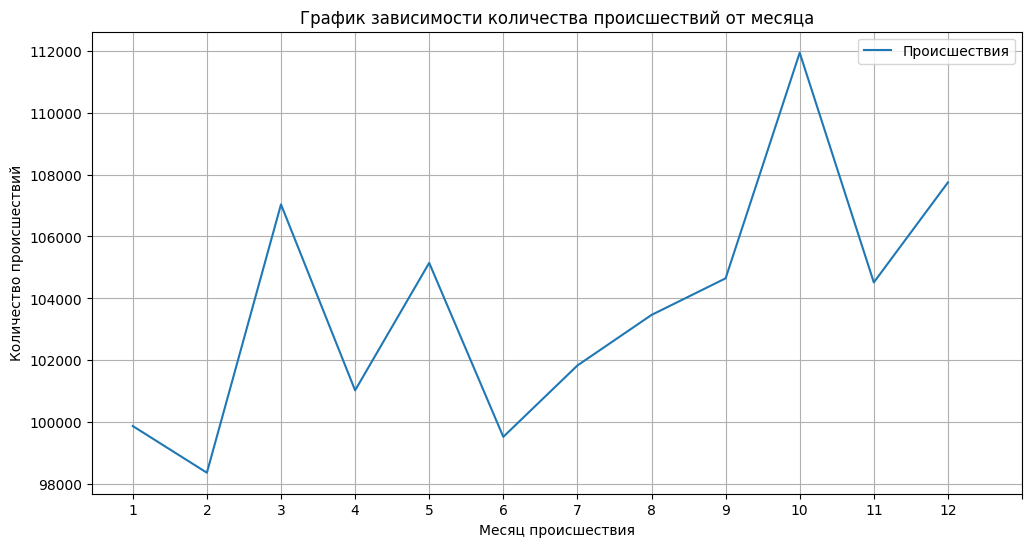

In [30]:
row.plot(x='collision_month', 
		 y='count', 
         title='График зависимости количества происшествий от месяца',
		 label='Происшествия',
		 ylabel='Количество происшествий',
         xlabel='Месяц происшествия',
         xticks=range(13),
		 grid=True)

Как видно из графика, наиболее аварийными месяцами являются октябрь, декабрь и март. Предположение: может быть связано с состоянием дороги в данные месяца (гололед, снег, дождь)

2. Скоро состоится первое совещание вашей рабочей группы. Чтобы обсуждение было конструктивным, каждый сотрудник должен понимать данные. Для этого вы должны создать подходящие аналитические задачи и поручить их решение коллегам. Примеры задач:
- Проведите анализ серьёзности повреждений транспортного средства, исходя из состояния дороги в момент ДТП (связать collisions и parties);
- Найдите самые частые причины ДТП (таблица parties).

2.1. Создайте не менее шести задач для коллег. Опирайтесь на примеры и таблицы. 
- Зависит ли сумма страховки от возраста автомобиля и типа кузова (parties и vehicles)?
- Получить соотношение типов КПП к типу кузова(vehicles)
- Провести зависимости между состоянием участника дтп и его виновностью (parties)
- Провести анализ трезвости участника и времени происшествия (collision и parties)
- Провести соответсвие между типом кузова и серьёзностью происшествия (vehicles, collision)
- Провести анализ между категорией нарушения и состоянием виновника аварии (parties и collision)

2.2. Пропишите порядок решения для двух задач из списка. Реализуйте его. Обязательное условие — решение этих задач должно включать связь не менее 2-х таблиц. Пример прописанного порядка:
- Создайте sql-запрос;
- Постройте график;
- Сделайте вывод.


### Провести соответсвие между типом кузова и серьёзностью происшествия с учетом виновности участника (vehicles и parties):
- создать запрос и достать из базы данных количество происшествий сгруппированных по кузовам и серьезности происшествия
- Построить barplot по типам кузова и количеству происшествий с разделением по серьезности происшествия
- Сделать вывод о связи типа кузова с серьезностью происшествия

In [31]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT v.vehicle_type, " \
			"c.collision_damage, " \
			"COUNT(DISTINCT c.case_id) " \
			"FROM collisions as c " \
			"JOIN vehicles as v on c.case_id=v.case_id " \
			"GROUP BY v.vehicle_type, " \
			"c.collision_damage " )
		row = cur.fetchall()
		row = pd.DataFrame(row)
		display(row)

,vehicle_type,collision_damage,count
0,coupe,fatal,6989
1,coupe,middle damage,109361
2,coupe,scratch,243096
3,coupe,severe damage,19720
4,hatchback,fatal,2577
5,hatchback,middle damage,16469
6,hatchback,scratch,18605
7,hatchback,severe damage,5314
8,minivan,fatal,510
9,minivan,middle damage,21745


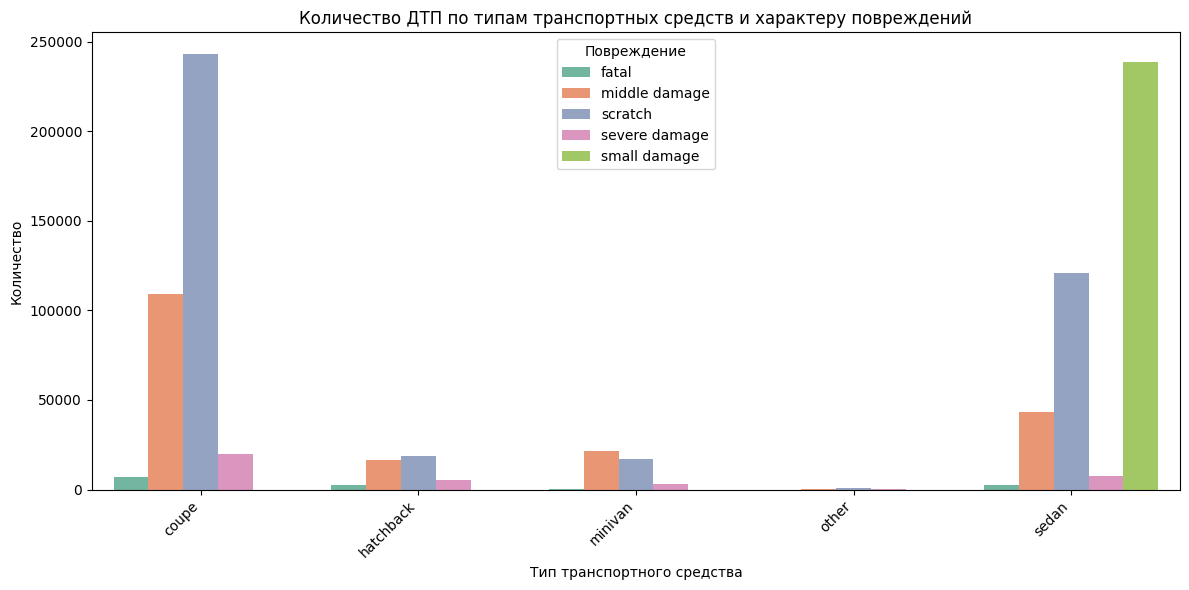

In [32]:
sns.barplot(data=row, x='vehicle_type', y='count', hue='collision_damage', palette='Set2')
plt.title('Количество ДТП по типам транспортных средств и характеру повреждений')
plt.xlabel('Тип транспортного средства')
plt.ylabel('Количество')
plt.legend(title='Повреждение')
plt.xticks(rotation=45, ha='right')  # если названия типов длинные
plt.tight_layout()
plt.show()

#### Вывод

Согласно данному исследованию:
- Типы кузовов седан и купе имеют наибольшее количество дтп, скорее всего из-за распростаренности данных типов кузовов. Поэтому дальше будем сравнивать данные два типа
- Фатальных повреждений больше у купе, скорее всего из-за большей предрасположенности данного кузова к спортивному вождению, а следовательно к опасным маневрам. Отсюда следуют и средние и серьезные повреждения
- Также у купе преобладает повреждения "царапина"
- У седанов преобладают малые повреждения.

### Зависит ли сумма страховки от возраста автомобиля и типа кузова (parties и vehicles)?
- Создать запрос, получить сумму страховых выплат по возрасту автомобиля, сгруппированному по типу кузова
- Построить несколько barplot друг в друге для каждого типа кузова
- Сделать выводы на основе общих сумм страховых выплат, средних и медианных значений

In [33]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT v.vehicle_type, " \
			"CASE " \
			"	WHEN v.vehicle_age <= 2 THEN 2" \
			"	WHEN v.vehicle_age <= 5 THEN 5" \
			"	WHEN v.vehicle_age <= 10 THEN 10" \
			"	WHEN v.vehicle_age <= 20 THEN 20" \
			"	ELSE 30 " \
			"END AS age, " \
			"SUM(p.insurance_premium), " \
			"AVG(p.insurance_premium) " \
			"FROM parties as p " \
			"JOIN vehicles as v on p.case_id=v.case_id " \
			"GROUP BY v.vehicle_type, " \
			"age " )
		row = cur.fetchall()
		row = pd.DataFrame(row)
		display(row)

,vehicle_type,age,sum,avg
0,coupe,2,982076,27.6166586991366947
1,coupe,5,12831200,32.9501915708812261
2,coupe,10,17965616,44.8296481872874314
3,coupe,20,3239294,58.1999712530094506
4,coupe,30,19773,39.3101391650099404
5,hatchback,2,651590,25.1297774692429326
6,hatchback,5,842828,32.8280750954272805
7,hatchback,10,1467002,47.4696479420139788
8,hatchback,20,494457,61.5762141967621420
9,hatchback,30,13142,39.4654654654654655


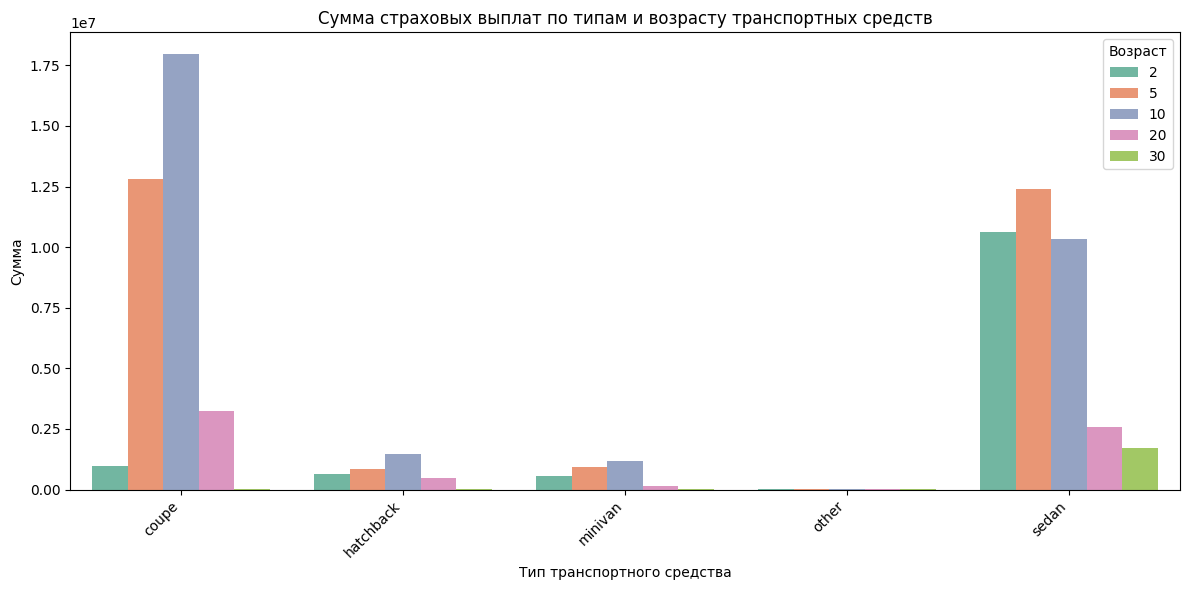

In [34]:
sns.barplot(data=row, x='vehicle_type', y='sum', hue='age', palette='Set2')
plt.title('Сумма страховых выплат по типам и возрасту транспортных средств')
plt.xlabel('Тип транспортного средства')
plt.ylabel('Сумма')
plt.legend(title='Возраст')
plt.xticks(rotation=45, ha='right')  # если названия типов длинные
plt.tight_layout()
plt.show()

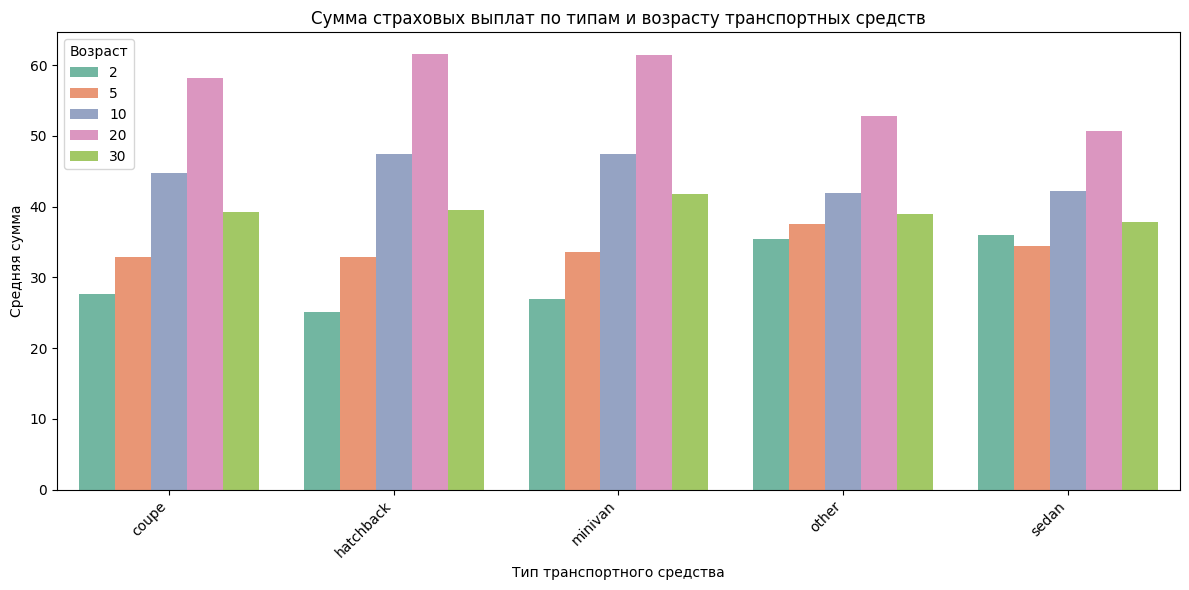

In [35]:
sns.barplot(data=row, x='vehicle_type', y='avg', hue='age', palette='Set2')
plt.title('Сумма страховых выплат по типам и возрасту транспортных средств')
plt.xlabel('Тип транспортного средства')
plt.ylabel('Средняя сумма')
plt.legend(title='Возраст')
plt.xticks(rotation=45, ha='right')  # если названия типов длинные
plt.tight_layout()
plt.show()

#### Вывод

Согласно данному исследованию:
- По суммам страховых выплат для разных типов кузовов ситуация аналогична предыдущему исследованию.
- Чаще всего выплаты приходятся для купе возрастом от 2 до 10 лет и для седанов до 10 лет
- Средняя сумма страховых выплат для всех типов кузовов примерно одинаковая. Но все же привалирует для авто возрастом от 10 до 20 лет.
- Самые маленькие страховые выплаты получают авто возрастом до 2 лет (для седанов до 5 лет)

## Создайте модель для оценки водительского риска

### Подготовьте набор данных на основе первичного предположения заказчика:
 
- Выберите тип виновника — только машина (car). **
- Возьмите случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
- Для моделирования возьмите данные только за 2012 год.
- Подготовка исходной таблицы должна проводиться с помощью sql-запроса.

In [36]:
# Доступ по индексу или имени столбца
with psycopg2.connect(**db_config) as conn:
	with conn.cursor(cursor_factory=RealDictCursor) as cur:
		cur.execute(
			"SELECT *," \
			"EXTRACT(MONTH FROM collision_date) as collision_month," \
			"EXTRACT (HOUR FROM collision_time) as collision_hour " \
			"FROM collisions as c " \
			"JOIN parties as p on c.case_id=p.case_id AND p.party_type = 'car' " \
			"JOIN vehicles as v on c.case_id = v.case_id AND p.party_number = v.party_number " \
			"WHERE c.collision_damage != 'scratch' " \
			"AND EXTRACT(HOUR FROM collision_time) IS NOT NULL " \
			"AND EXTRACT(YEAR FROM c.collision_date) = 2012")
		rows = cur.fetchall()
		df_origin = pd.DataFrame(rows)
		display(df_origin)

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,...,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age,collision_month,collision_hour
0,5600885,3607,san bernardino,400.0,north,0.0,clear,None,small damage,2,...,1,43.0,had not been drinking,None,0.0,sedan,auto,8.0,4,22
1,5449062,0708,contra costa,21.0,east,0.0,clear,None,small damage,2,...,0,54.0,had not been drinking,None,0.0,sedan,manual,10.0,1,2
2,5608728,0109,alameda,500.0,west,0.0,cloudy,highway,small damage,2,...,0,41.0,had not been drinking,None,0.0,sedan,auto,5.0,3,18
3,5608860,4303,santa clara,160.0,east,0.0,clear,None,small damage,2,...,0,28.0,had not been drinking,None,0.0,sedan,auto,0.0,4,11
4,5609619,1949,los angeles,16.0,east,0.0,cloudy,None,small damage,1,...,1,44.0,None,under drug influence,0.0,sedan,auto,1.0,4,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56155,5642210,5002,stanislaus,210.0,None,0.0,clear,None,middle damage,2,...,1,32.0,"had been drinking, under influence",None,NaN,coupe,auto,5.0,6,0
56156,5642335,1942,los angeles,151.0,east,0.0,clear,None,middle damage,2,...,1,39.0,had not been drinking,None,0.0,coupe,manual,6.0,5,16
56157,5667033,1915,los angeles,0.0,None,1.0,clear,None,middle damage,2,...,0,34.0,had not been drinking,None,0.0,coupe,manual,5.0,5,13
56158,5667756,4315,santa clara,0.0,None,1.0,clear,intersection,middle damage,2,...,1,61.0,had not been drinking,None,0.0,coupe,manual,9.0,4,12


### Проведите первичный отбор факторов, необходимых для модели.

Изучите описание факторов. Нужно отобрать те, которые могут влиять на вероятность ДТП. Будет хорошо, если вы аргументируете свой выбор. 

In [37]:
df_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56160 entries, 0 to 56159
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      56160 non-null  object 
 1   county_city_location         56160 non-null  object 
 2   county_location              56160 non-null  object 
 3   distance                     56160 non-null  float64
 4   direction                    43158 non-null  object 
 5   intersection                 55985 non-null  float64
 6   weather_1                    55992 non-null  object 
 7   location_type                25900 non-null  object 
 8   collision_damage             56160 non-null  object 
 9   party_count                  56160 non-null  int64  
 10  primary_collision_factor     56049 non-null  object 
 11  pcf_violation_category       55396 non-null  object 
 12  type_of_collision            55852 non-null  object 
 13  motor_vehicle_in

Проанализируем столбцы
- case_id - параметр не нужен как id
- collision_date - необходим но в другом формате. В формате месяцев
- collision_time - также нужен только в формате дня/ночи
- intersection - необходим так как является зоной повышенного риска
- weather_1 - влияет на видимсоть и сцепление
- collision_damage - скорее не нужен, так как является следствием
- primary_collision_factor - данный фактор нет возможности выявить перед выдачей
- road_surface - влияет напрямую на сцепление с дорогой
- lighting - напрямую влияет на видимость
- county_city_location - влияет так как по нему можно увидеть общие закономерности в регионах, что может отражаться в качестве дорожной сети
- county_location - не нужен, достаточно предыдущеко признака
- direction - важный параметр в совокупности с временем
- distance - также косвенно может влиять на качество дорожной сети
- location_type - влияет на поведение участников дорожного движения
- party_count - не нужен так как является следствием
- pcf_violation_category - не нужен, является онлайн признаком, но поможет при анализе для выбора средства предостережения
- type_of_collision - также является следствием, необходим только для анализа
- motor_vehicle_involved_with - следствие
- road_condition_1 - необходим, так как влияет на качество дороги
- party_type, party_number - являются следствием, признак не нужен
- at_fault - целевой признак
- insurance_premium - следствие
- party_drug_physical - является онлайн признаком, можно учесть только с помощью датчиков или предварительного опроса. В нашем случае не используем
- party_sobriety - то же самое, что и предыдущий
- cellphone_in_use - необходим, так как может влият на внимательность автомобилиста
- vehicle_type - необходим, так как влияет на поведение автомобиля
- vehilcle_transmission - то же самое
- vehicle_age - то же самое

In [38]:
columns = [
    'collision_month',
    'collision_hour',
    'intersection',
    'weather_1',
    'road_surface',
    'lighting',
    'county_city_location',
    'direction',
    'distance',
    'location_type',
    'road_condition_1',
    'at_fault',
    'cellphone_in_use',
    'vehicle_type',
    'vehicle_transmission',
    'vehicle_age'
]

In [39]:
df = df_origin[columns]
dict_1 = {'df' : df}

### Проведите статистическое исследование отобранных факторов.
По результату исследовательского анализа внесите корректировки, если они нужны. Сделайте вывод.
Если необходимо, категоризируйте исходные данные, проведите масштабирование.
Подготовьте обучающую и тестовую выборки.

In [40]:
df_info(dict_1)

df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56160 entries, 0 to 56159
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   collision_month       56160 non-null  object 
 1   collision_hour        56160 non-null  object 
 2   intersection          55985 non-null  float64
 3   weather_1             55992 non-null  object 
 4   road_surface          55814 non-null  object 
 5   lighting              56009 non-null  object 
 6   county_city_location  56160 non-null  object 
 7   direction             43158 non-null  object 
 8   distance              56160 non-null  float64
 9   location_type         25900 non-null  object 
 10  road_condition_1      55911 non-null  object 
 11  at_fault              56160 non-null  int64  
 12  cellphone_in_use      51696 non-null  float64
 13  vehicle_type          56160 non-null  object 
 14  vehicle_transmission  55303 non-null  object 
 15  vehicle_age     

,collision_month,collision_hour,intersection,weather_1,road_surface,lighting,county_city_location,direction,distance,location_type,road_condition_1,at_fault,cellphone_in_use,vehicle_type,vehicle_transmission,vehicle_age
0,4,22,0.0,clear,dry,dark with street lights,3607,north,400.0,None,normal,1,0.0,sedan,auto,8.0
1,1,2,0.0,clear,dry,dark with street lights,0708,east,21.0,None,normal,0,0.0,sedan,manual,10.0
2,3,18,0.0,cloudy,dry,dusk or dawn,0109,west,500.0,highway,normal,0,0.0,sedan,auto,5.0
3,4,11,0.0,clear,dry,daylight,4303,east,160.0,None,normal,0,0.0,sedan,auto,0.0
4,4,8,0.0,cloudy,dry,daylight,1949,east,16.0,None,normal,1,0.0,sedan,auto,1.0


----------------------------------------------------




Необходимо обработать пропуски в столбцах intersection и cellphone_in_use. Если данные в этих бинарных признаках не указаны, то скорее всего были либо сомнения, либо при заполнении пропустили данный пункт, так как он не соотвествовал обстановке происшествия. Следовательно данные признаки не влияли на исход данного происшествия. Поэтому пометим остуствующие значения нулем (0)

Также надо привести столбцы intersection, cellphone_in_use, at_fault, collision_month, collision_hour к типу данных int

In [41]:
# dict_1['df']['county_city_location'] = pd.to_numeric(dict_1['df']['county_city_location'])
dict_1['df']['intersection'] = dict_1['df']['intersection'].fillna(0).astype(int)
dict_1['df']['cellphone_in_use'] = dict_1['df']['cellphone_in_use'].fillna(0).astype(int)
dict_1['df']['at_fault'] = dict_1['df']['at_fault'].astype(int)
dict_1['df']['collision_month'] = dict_1['df']['collision_month'].astype(int)
dict_1['df']['collision_hour'] = dict_1['df']['collision_hour'].astype(int)

C:\Users\navoh\AppData\Local\Temp\ipykernel_17612\200534734.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dict_1['df']['intersection'] = dict_1['df']['intersection'].fillna(0).astype(int)
C:\Users\navoh\AppData\Local\Temp\ipykernel_17612\200534734.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dict_1['df']['cellphone_in_use'] = dict_1['df']['cellphone_in_use'].fillna(0).astype(int)
C:\Users\navoh\AppData\Local\Temp\ipykernel_17612\200534734.py:4: SettingWithCopyWarning: 
A value is trying to be s

In [42]:
df_pred(dict_1)

df
Удалено явных дубликатов 295
Максимум пропусков 30260
----------------------------------------------------




In [43]:
df_value(dict_1)

Датафрейм: df




clear      44758
cloudy      8387
raining     2173
fog          180
snowing      155
other         33
wind          11
Name: weather_1, dtype: int64

dry         49886
wet          5238
snowy         354
slippery       43
Name: road_surface, dtype: int64

daylight                                   37838
dark with street lights                    10931
dark with no street lights                  5052
dusk or dawn                                1758
dark with street lights not functioning      135
Name: lighting, dtype: int64

1942    6811
1900    2211
3711    1332
3400    1080
3600    1002
        ... 
4118       1
1701       1
1102       1
4701       1
0110       1
Name: county_city_location, Length: 496, dtype: int64

...

highway         21223
ramp             3253
intersection     1336
Name: location_type, dtype: int64

normal            53701
construction        994
obstruction         247
other               227
holes               219
loose material      127
reduced width        71
flooded              32
Name: road_condition_1, dtype: int64

sedan    36979
coupe    18882
other        4
Name: vehicle_type, dtype: int64

manual    29120
auto      25891
Name: vehicle_transmission, dtype: int64



----------------------------------------------------




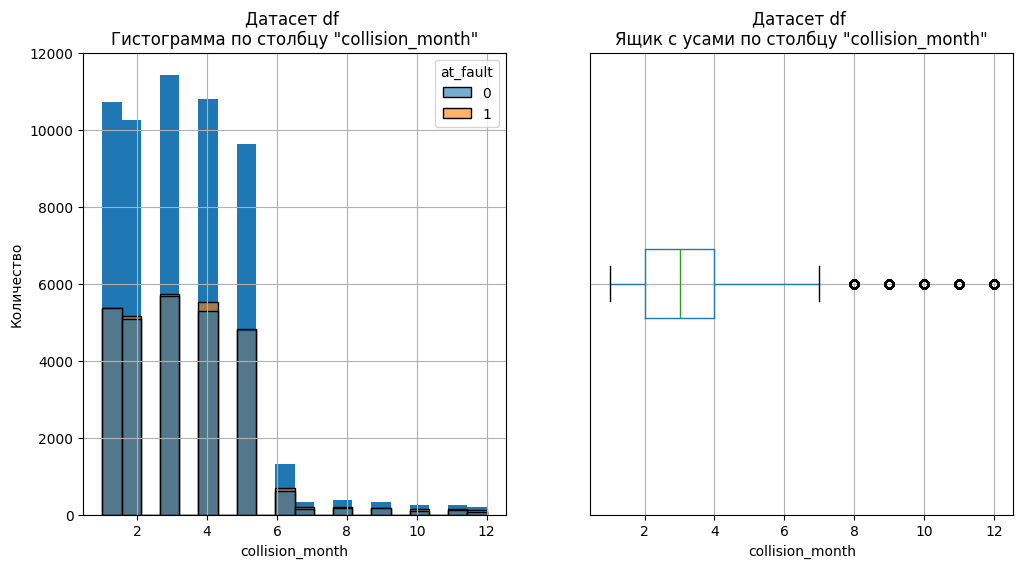

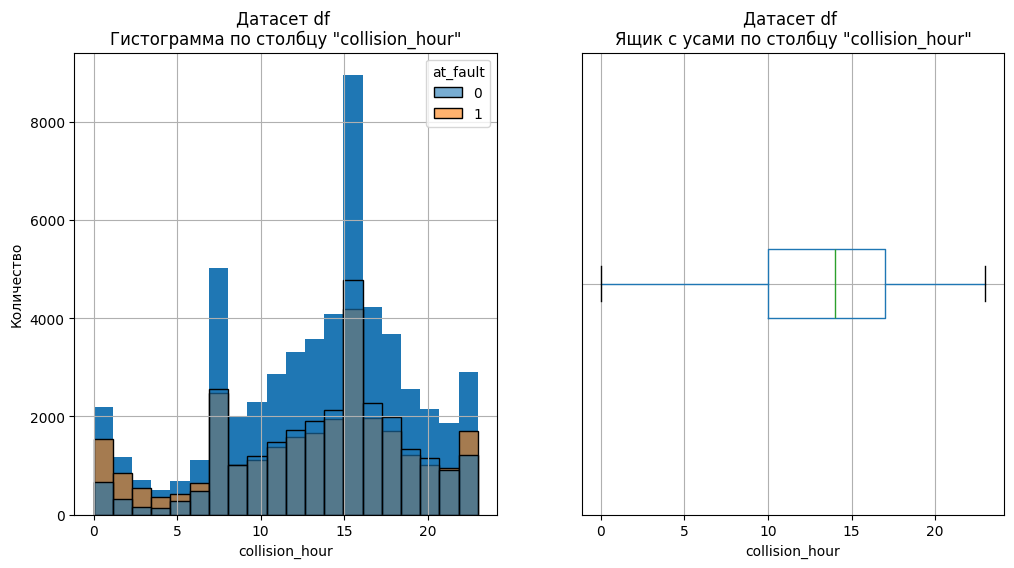

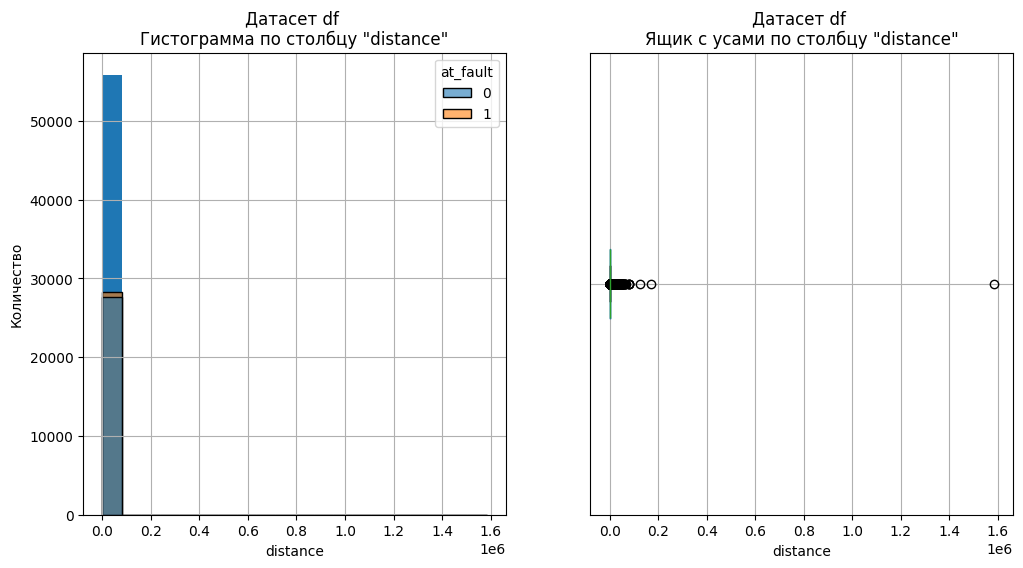

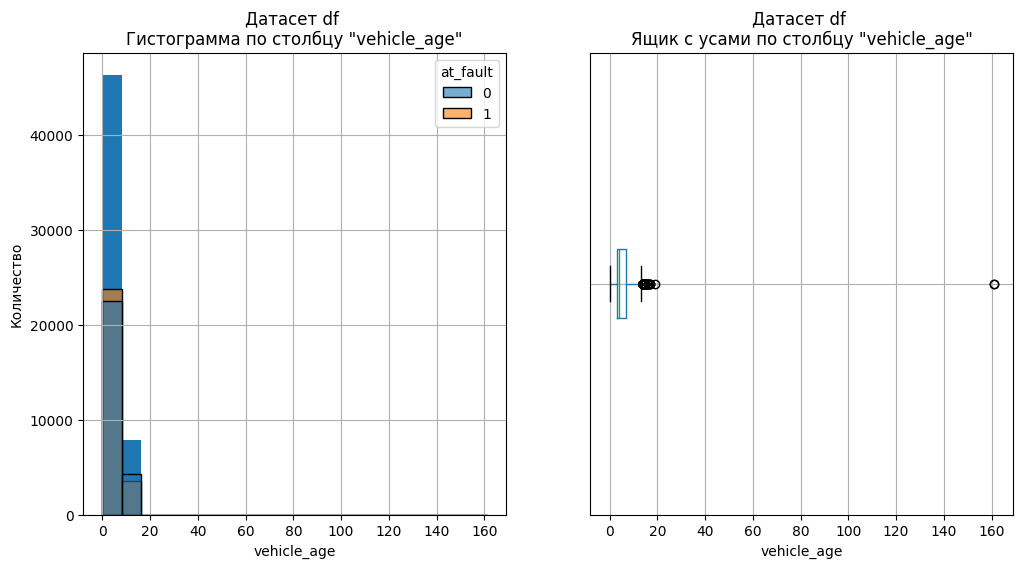

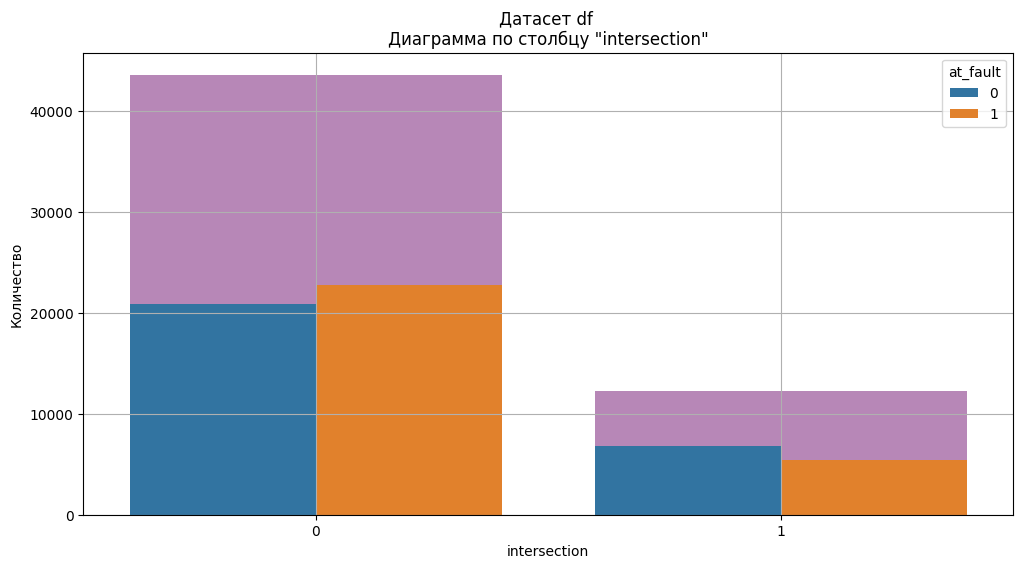

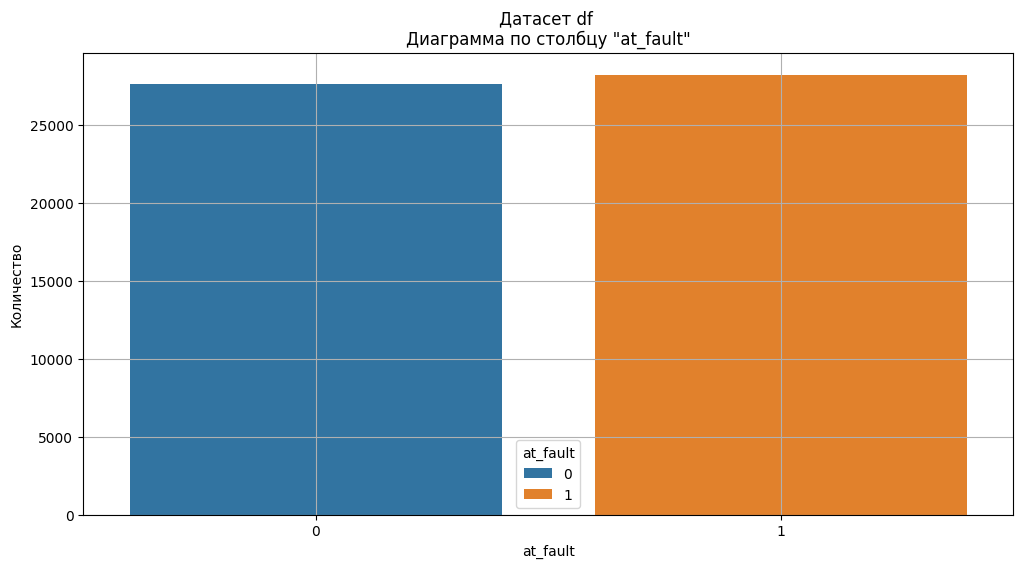

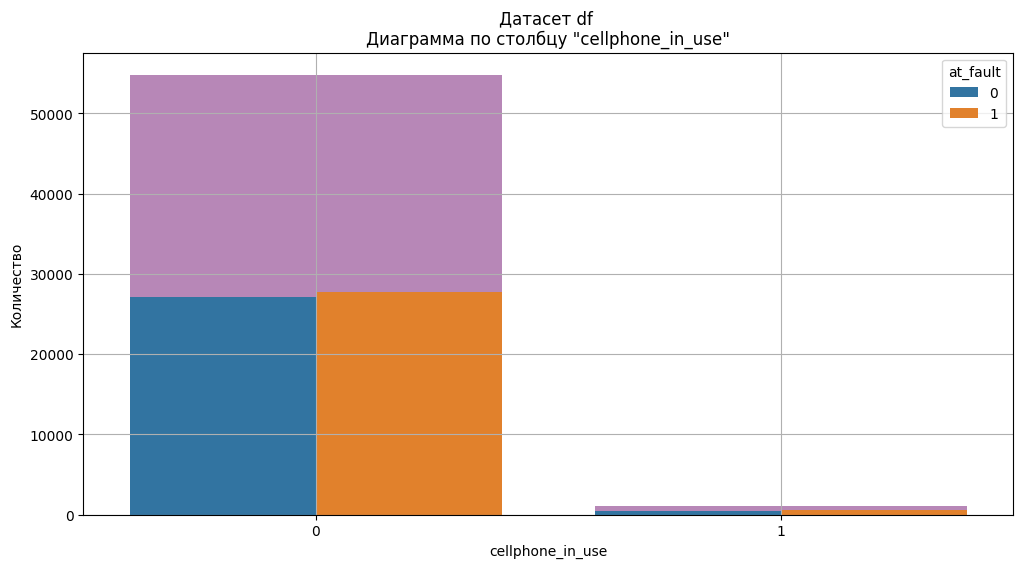

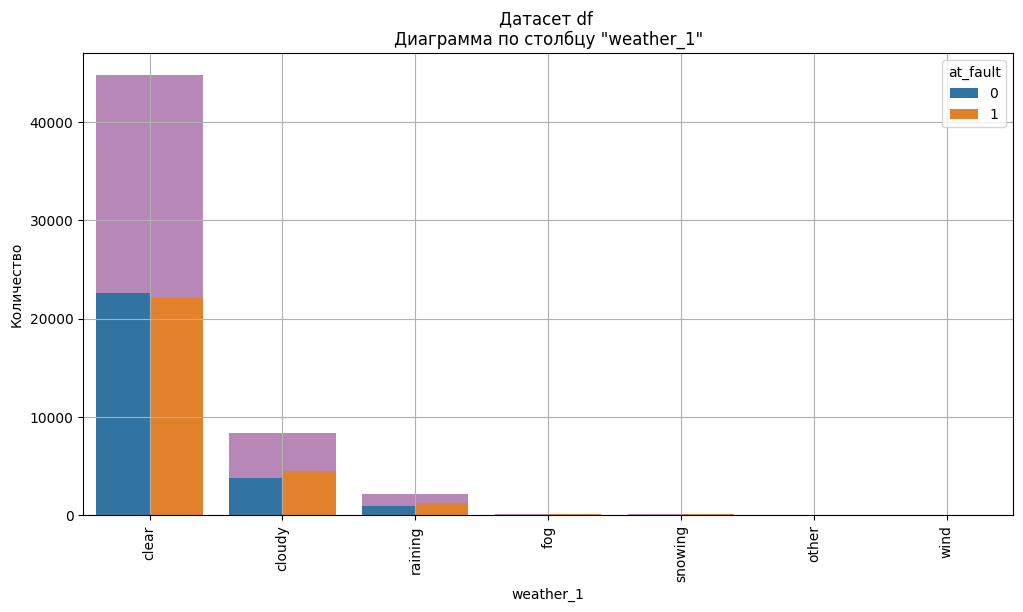

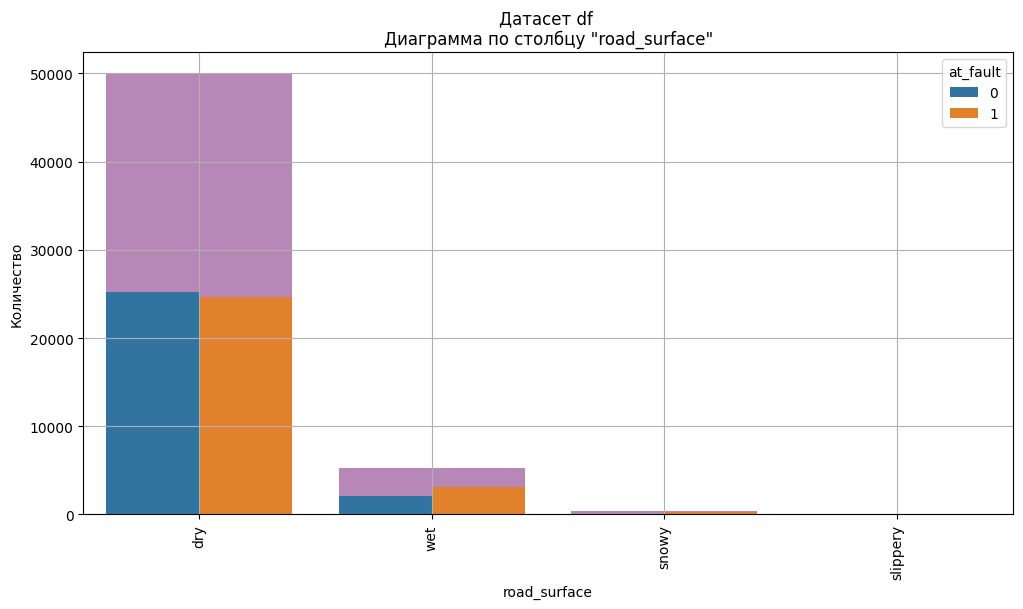

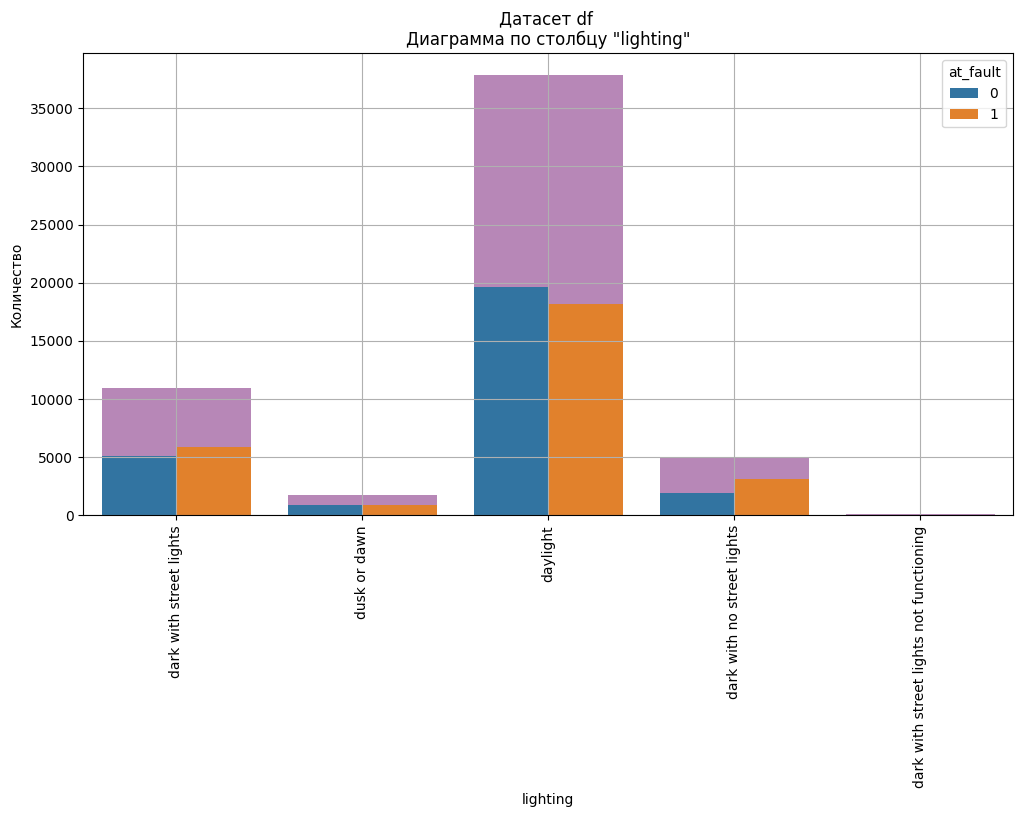

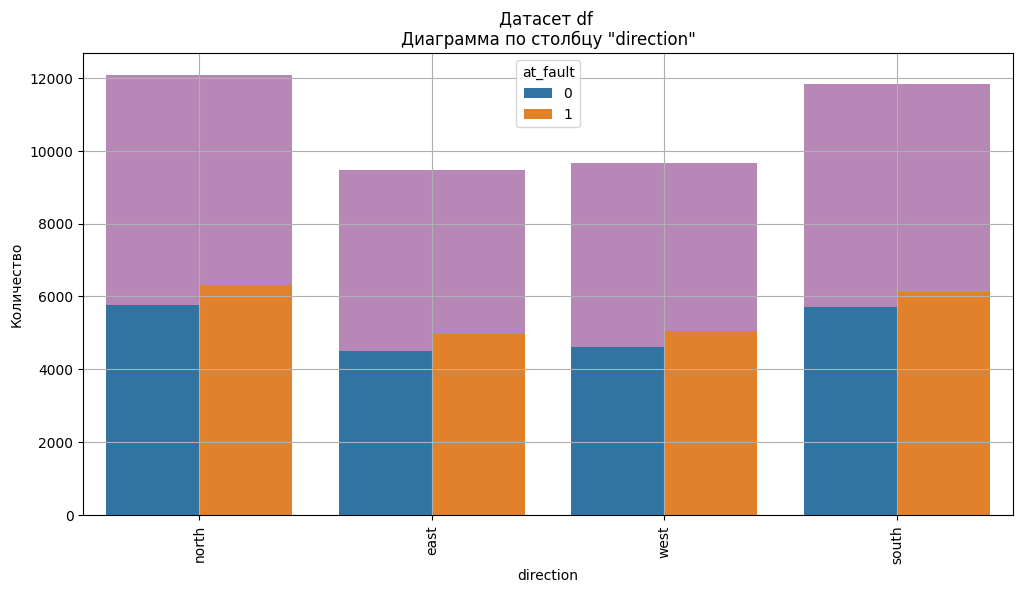

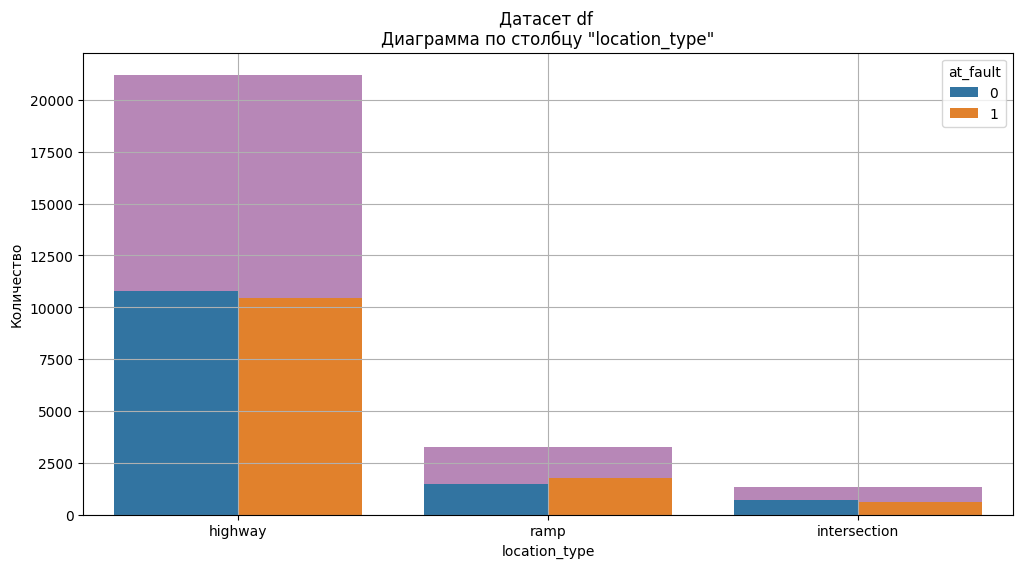

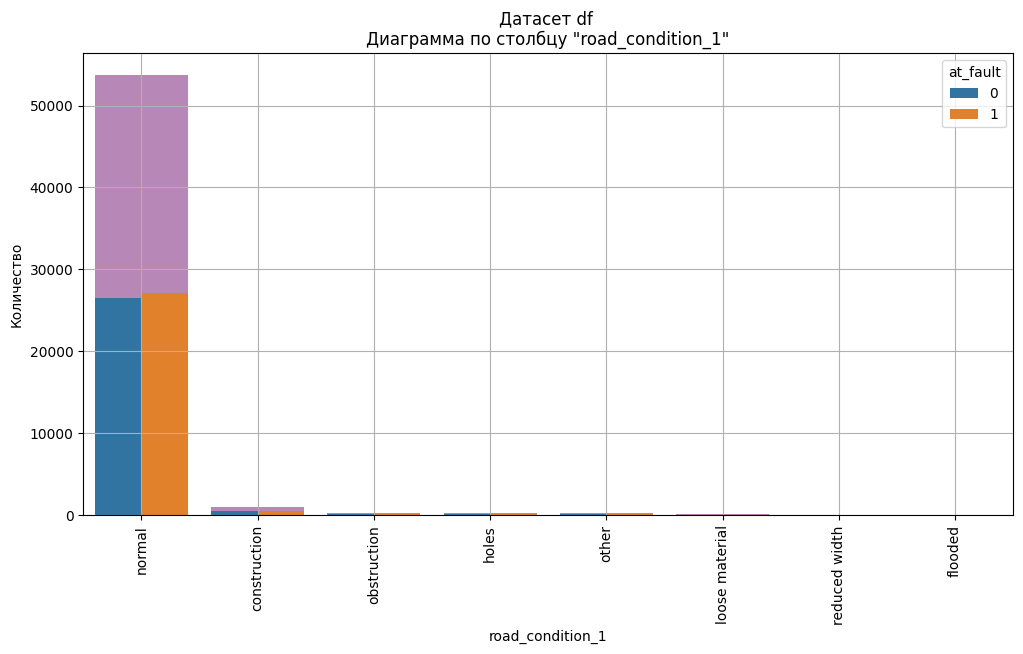

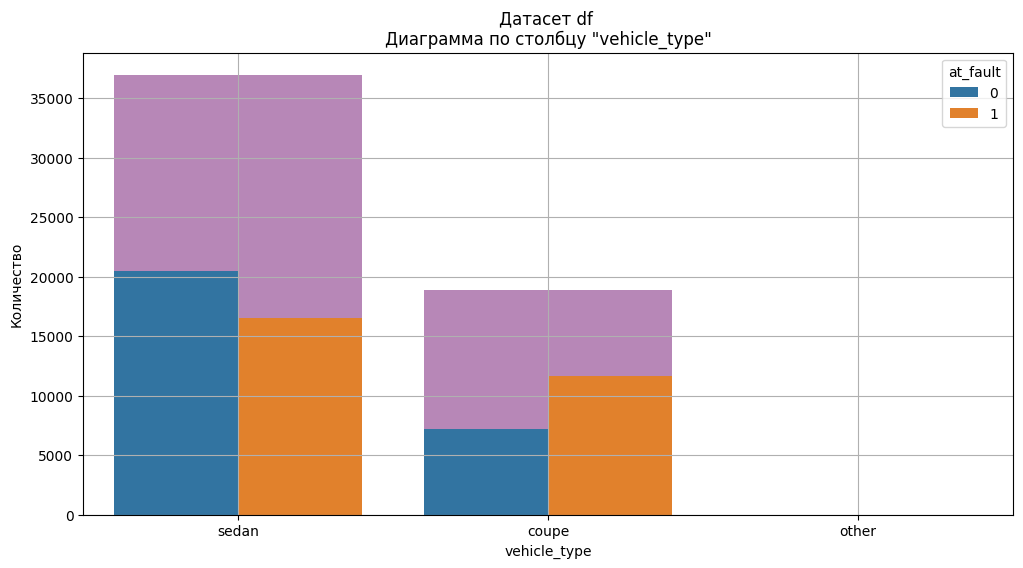

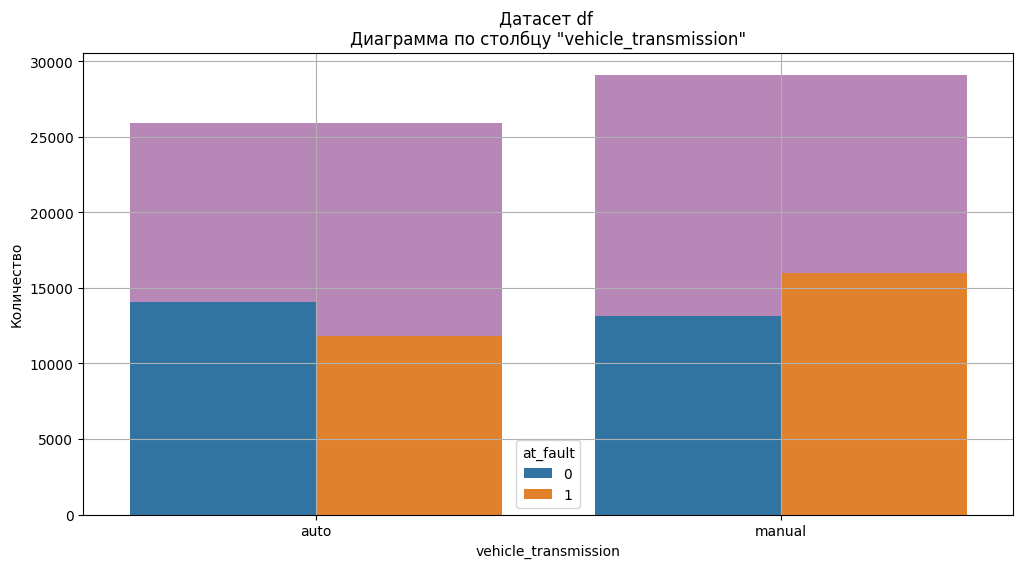

In [44]:
df_hist_dict(dict_1, hue='at_fault')

Согласно гистограммам есть выброс у данных по признакам vehicle_age и distance. Устраним их.

In [45]:
dict_1['df'] = dict_1['df'][dict_1['df']['vehicle_age'] < 40]
dict_1['df'] = dict_1['df'][dict_1['df']['distance'] < 1e6]

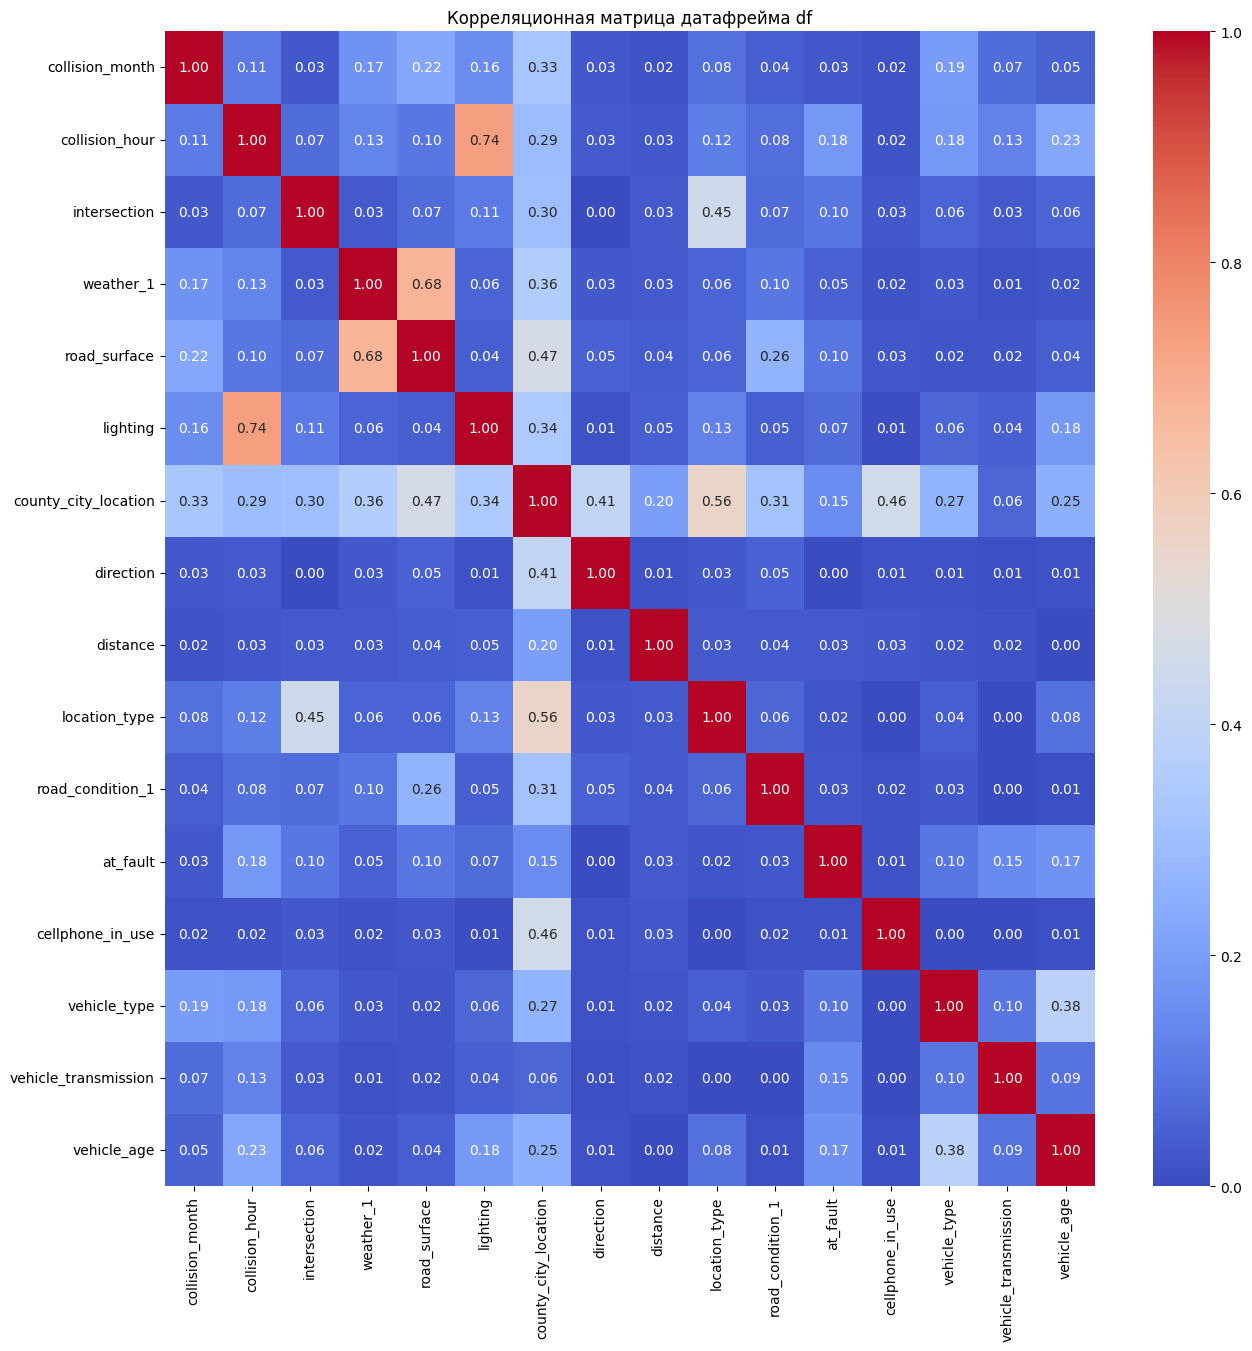

In [46]:
df_corr(dict_1, 
        continuous_features= ['distance']
        )

#### По результатам EDA

- Были выявлены и устранены незначительные выбросы.
- Построены гистограммы и матрица коррелции, по которым не выявлено мульткорреляции признаков, также отсутсвуют косвенно целевые признаки.
- По многим признакам виден значительный дисбаланс категорий
- По отношению к at_fault имеется заметный дисбаланс в признаках vehicle_age, collision_hour, vehicle_type, vehicle_transmission

### Подготовка данных

In [47]:
dict_1['df'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 54182 entries, 0 to 56159
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   collision_month       54182 non-null  int32  
 1   collision_hour        54182 non-null  int32  
 2   intersection          54182 non-null  int32  
 3   weather_1             54017 non-null  object 
 4   road_surface          53855 non-null  object 
 5   lighting              54033 non-null  object 
 6   county_city_location  54182 non-null  object 
 7   direction             41898 non-null  object 
 8   distance              54182 non-null  float64
 9   location_type         25390 non-null  object 
 10  road_condition_1      53947 non-null  object 
 11  at_fault              54182 non-null  int32  
 12  cellphone_in_use      54182 non-null  int32  
 13  vehicle_type          54182 non-null  object 
 14  vehicle_transmission  53608 non-null  object 
 15  vehicle_age        

In [48]:
X = dict_1['df'].drop(columns=['at_fault'], axis=1)
y = dict_1['df']['at_fault']

# разделение на тренировочную и тестовую выборки
X_train_original, X_test_original, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    # stratify = y
                                                    )

X_train_original.shape, y_train.shape, X_test_original.shape, y_test.shape

((43345, 15), (43345,), (10837, 15), (10837,))

In [49]:
# создаём списки с названиями признаков
cat_columns = ['collision_month', 
               'collision_hour', 
               'intersection', 
               'weather_1',
               'road_surface', 
               'lighting', 
               'county_city_location', 
               'direction',
               'location_type', 
               'road_condition_1', 
               'cellphone_in_use', 
               'vehicle_type', 
               'vehicle_transmission'
               ]
num_columns = ['distance',
               'vehicle_age'
               ]
ohe_columns = cat_columns

for col in cat_columns:
    X_train_original[col] = X_train_original[col].fillna('unknown').astype(str)
    X_test_original[col] = X_test_original[col].fillna('unknown').astype(str)

In [50]:
# создаём пайплайны для подготовки признаков
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
     ('ohe', OneHotEncoder(drop='first', 
                           handle_unknown='infrequent_if_exist',
                           sparse_output=False 
                           ))
    ]
    )

num_pipe = Pipeline(
    [
     ('standardscaler', StandardScaler())
	]
    )

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', num_pipe, num_columns),
    ], 
    remainder='passthrough'
	)


In [51]:
X_train = data_preprocessor.fit_transform(X_train_original, y_train)
X_test = data_preprocessor.transform(X_test_original)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Данные подготовлены для обучения моделей

## Найдите лучшую модель
Смоделируйте не менее 3-х типов моделей с перебором гиперпараметров.
Выберите метрику для оценки модели, исходя из поставленной бизнесом задачи. Обоснуйте свой выбор.
Оформите вывод в виде сравнительной таблицы.

Для оценки моделей выбрана метрика ROC-AUC, так как позволяет увидеть общую способность модели давать верные ответы. Дополнительной метрикой является F1, так как необходимо соблюдать баланс между полнотой и точностью.

### Выбор базовой модели

#### LogisticRegression

In [52]:
pipe_final = Pipeline([
    # ('poly_features', PolynomialFeatures(degree=2, order='C')),
    ('feature_selection', SelectKBest(score_func=f_classif, k=100)),
    ('models', LogisticRegression(random_state=RANDOM_STATE))
])

In [53]:
param_grid_lr = [
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1,10)
    }
]

In [54]:
randomized_search_lr = df_randomized_search_classifier(pipe_final, param_grid_lr, n_iter=20)

In [55]:
%%time
randomized_search_lr.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n')
randomized_search_lr.best_estimator_

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [146 252 367 438 516 537] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76 106 133 241] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature

Лучшая модель и её параметры:


CPU times: total: 59.2 s
Wall time: 1min 2s


Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models',
                 LogisticRegression(C=1, penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [56]:
lr_score = randomized_search_lr.best_score_
print(f'Метрика ROC-AUC: {lr_score:.4f}')

Метрика ROC-AUC: 0.6441


In [57]:
lr_model = randomized_search_lr.best_estimator_
lr_model

Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models',
                 LogisticRegression(C=1, penalty='l1', random_state=42,
                                    solver='liblinear'))])

#### DecisionTreeClassifier

In [58]:
param_grid_tree = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE,
                                        #   class_weight='balanced'
                                          )],
        'models__max_depth': range(2,50,5),
        'models__max_features': range(2,30,5),
        'models__min_samples_split':range(5,50,5),
        'models__min_samples_leaf':range(5,50,5),
        # 'feature_selection__k': range(1, 16, 2),
    }
]

In [59]:
randomized_search_tree = df_randomized_search_classifier(pipe_final, param_grid_tree, n_iter=20)

In [60]:
%%time
randomized_search_tree.fit(X_train, y_train)

print(F'Метрика ROC-AUC: {randomized_search_tree.best_score_}')
print('Лучшая модель и её параметры:\n\n')
randomized_search_tree.best_estimator_

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [146 252 367 438 516 537] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76 106 133 241] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [247 26

Метрика ROC-AUC: 0.6443345608687897
Лучшая модель и её параметры:


CPU times: total: 1min 32s
Wall time: 1min 34s


Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models',
                 DecisionTreeClassifier(max_depth=17, max_features=12,
                                        min_samples_leaf=40,
                                        min_samples_split=15,
                                        random_state=42))])

In [61]:
tree_score = randomized_search_tree.best_score_
print(f'Метрика ROC-AUC: {tree_score:.4f}')

Метрика ROC-AUC: 0.6443


In [62]:
tree_model = randomized_search_tree.best_estimator_
tree_model

Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models',
                 DecisionTreeClassifier(max_depth=17, max_features=12,
                                        min_samples_leaf=40,
                                        min_samples_split=15,
                                        random_state=42))])

#### KNN

In [63]:
param_grid_knn = [
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier(n_jobs=-1)],
        'models__n_neighbors': range(5, 100, 10),
        # 'feature_selection__k': range(1, 13, 2),
    },
]

In [64]:
randomized_search_knn = df_randomized_search_classifier(pipe_final, param_grid_knn, n_iter=20)

In [65]:
%%time
randomized_search_knn.fit(X_train, y_train)

print(F'Метрика ROC-AUC: {randomized_search_knn.best_score_}')
print('Лучшая модель и её параметры:\n\n')
randomized_search_knn.best_estimator_

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [146 252 367 438 516 537] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76 106 133 241] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [247 26

Метрика ROC-AUC: 0.6435141105844057
Лучшая модель и её параметры:


CPU times: total: 15min 56s
Wall time: 5min 6s


Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models', KNeighborsClassifier(n_jobs=-1, n_neighbors=95))])

In [66]:
knn_score = randomized_search_knn.best_score_
print(f'Метрика ROC-AUC: {knn_score:.4f}')

Метрика ROC-AUC: 0.6435


In [67]:
knn_model = randomized_search_knn.best_estimator_
knn_model

Pipeline(steps=[('feature_selection', SelectKBest(k=100)),
                ('models', KNeighborsClassifier(n_jobs=-1, n_neighbors=95))])

#### Выбор лучшей базовой модели

In [93]:
if lr_score > tree_score and \
   lr_score > knn_score:
    base_model = lr_model
    base_score = lr_score
elif tree_score > knn_score:
    base_model = tree_model
    base_score = tree_score
else:
    base_model = knn_model
    base_score = knn_score
    
name_base = type(base_model.named_steps['models']).__name__
    
print(f'Лучшая базовая модель: {name_base}')
print(f'Метрика ROC-AUC на CV: {base_score:.4f}')

Лучшая базовая модель: DecisionTreeClassifier
Метрика ROC-AUC на CV: 0.6443


### Модель Catboost

In [94]:
train_data = X_train_original.copy()
train_labels = y_train.copy()
test_data = X_test_original.copy()

In [95]:
cv_dataset = Pool(data=train_data,
                  label=train_labels,
                  cat_features=cat_columns
                  )

params = {"iterations": 800,
          "depth": 7,
          'learning_rate': 0.17,
          "loss_function": "Logloss",
          "verbose": False,
          'eval_metric': 'AUC',
          'custom_metric': ['F1'],
          'random_state': RANDOM_STATE,
          'auto_class_weights': 'Balanced'}

scores = cv(cv_dataset,
            params,
            fold_count=5,
            shuffle=True,
            plot=True)

f1_mean = scores['test-F1-mean'].iloc[-1]
f1_std  = scores['test-F1-std'].iloc[-1]
AUC_mean = scores['test-AUC-mean'].iloc[-1]
AUC_std  = scores['test-AUC-std'].iloc[-1]

print(f'F1 CV: {f1_mean:.4f} ± {f1_std:.4f}')
print(f'AUC CV: {AUC_mean:.4f} ± {AUC_std:.4f}')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]

bestTest = 0.7206680473
bestIteration = 376

Training on fold [1/5]

bestTest = 0.7231791356
bestIteration = 372

Training on fold [2/5]

bestTest = 0.7129112611
bestIteration = 198

Training on fold [3/5]

bestTest = 0.7216268265
bestIteration = 170

Training on fold [4/5]

bestTest = 0.725003856
bestIteration = 284

F1 CV: nan ± nan
AUC CV: 0.7128 ± 0.0047


#### Перебор гиперпараметров Catboost

In [96]:
# 1. Определяем функцию цели
def objective(trial):
    # Задаем пространство для поиска гиперпараметров
    params = {
        "iterations": trial.suggest_int("iterations", 100, 800, step=50),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 1e-5, 10, log=True),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "custom_metric": ["F1"],
        "auto_class_weights": "Balanced",
        "verbose": False,
        "random_seed": RANDOM_STATE
    }
    
    # Настройка стратифицированной кросс-валидации
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
	# Callback для прунинга
    pruning_callback = CatBoostPruningCallback(trial, "AUC")  # Укажите метрику для отслеживания
    
    # Выполнение кросс-валидации
    cv_results = cv(
        pool=cv_dataset,
        params=params,
        fold_count=5,
        partition_random_seed=RANDOM_STATE,
        shuffle=True,
        plot=False,
        stratified=True,     # Использовать стратифицированные фолды
        type="Classical",
        verbose=False
    )
    
	# Проверка, не было ли испытание прервано
    pruning_callback.check_pruned()
    
    # Возвращаем среднее значение F1-меры
    return cv_results["test-AUC-mean"].max()

In [97]:
# %%time
# # 2. Запускаем оптимизацию
# study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
# study.optimize(objective, n_trials=50, show_progress_bar=True)
# catboost_best_params = study.best_params
# catboost_best_value = study.best_value

# print(f"Лучшие параметры: {catboost_best_params}")
# print(f"Лучшее значение ROC-AUC: {catboost_best_value:.4f}")

In [98]:

# 3. Получаем и обучаем финальную модель с лучшими параметрами
catboost_best_params = {'iterations': 800, 
               			'depth': 7, 
               			'learning_rate': 0.17186165021917388, 
               			'l2_leaf_reg': 6.844679581992418, 
               			'bagging_temperature': 0.7955878990054338, 
               			'random_strength': 0.14362386912185224,
                        "loss_function": "Logloss",
          				"verbose": False,
          				'eval_metric': 'AUC',
          				'custom_metric': ['F1'],
          				'random_state': RANDOM_STATE,
          				'auto_class_weights': 'Balanced'}

catboost_model = CatBoostClassifier(**catboost_best_params)

In [99]:
scores = cv(cv_dataset,
            catboost_best_params,
            fold_count=5,
            shuffle=True,
            plot=True)

f1_mean = scores['test-F1-mean'].iloc[-1]
f1_std  = scores['test-F1-std'].iloc[-1]
AUC_mean = scores['test-AUC-mean'].iloc[-1]
AUC_std  = scores['test-AUC-std'].iloc[-1]

catboost_score = AUC_mean

print(f'F1 CV: {f1_mean:.4f} ± {f1_std:.4f}')
print(f'AUC CV: {AUC_mean:.4f} ± {AUC_std:.4f}')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]

bestTest = 0.7248949702
bestIteration = 89

Training on fold [1/5]

bestTest = 0.7228644613
bestIteration = 142

Training on fold [2/5]

bestTest = 0.7183643304
bestIteration = 192

Training on fold [3/5]

bestTest = 0.7189864524
bestIteration = 167

Training on fold [4/5]

bestTest = 0.7284738726
bestIteration = 138

F1 CV: nan ± nan
AUC CV: 0.7160 ± 0.0032


In [100]:
%%time
catboost_model.fit(train_data, train_labels, cat_features=cat_columns, verbose=100)

0:	total: 464ms	remaining: 6m 11s
100:	total: 21.6s	remaining: 2m 29s
200:	total: 47.5s	remaining: 2m 21s
300:	total: 1m 8s	remaining: 1m 52s
400:	total: 1m 28s	remaining: 1m 28s
500:	total: 1m 49s	remaining: 1m 5s
600:	total: 2m 10s	remaining: 43.1s
700:	total: 2m 30s	remaining: 21.3s
799:	total: 2m 51s	remaining: 0us
CPU times: total: 13min 25s
Wall time: 2min 53s


### Модель нейронной сети

In [101]:
# Определение гиперпараметров
num_epochs = 1000
epoch_counter = 10
difficult = 1e-3

In [102]:
# Функция определения весов модели
def init_weights(layer):
    if type(layer) == nn.Linear: # Проверка, что слой – полносвязный
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(layer.bias)

In [103]:
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(X_train, 
															  y_train,
															  test_size = TEST_SIZE, 
															  random_state=RANDOM_STATE,
															  # stratify = y
															  )

X_nn_train = torch.FloatTensor(X_nn_train)
X_nn_val = torch.FloatTensor(X_nn_val)
X_nn_test = torch.FloatTensor(X_test)
y_nn_train = torch.FloatTensor(y_nn_train.values).float().view(-1, 1)
y_nn_val = torch.FloatTensor(y_nn_val.values).float().view(-1, 1)
y_nn_test = torch.FloatTensor(y_test.values).float().view(-1, 1)

train_dataset = TensorDataset(X_nn_train, y_nn_train)
val_dataset = TensorDataset(X_nn_val, y_nn_val)
test_dataset = TensorDataset(X_nn_test, y_nn_test)

#### Обучение базовой нейронной модели

In [104]:
n_neurons = [X_nn_train.shape[1], 64, 32, 16, 1]
net_layers = []

for i in range(1, len(n_neurons) - 1):
	net_layers.append(nn.Linear(n_neurons[i-1], n_neurons[i]))
	net_layers.append(nn.ReLU())

net_layers.append(nn.Linear(n_neurons[-2], n_neurons[-1]))

net_1 = nn.Sequential(*net_layers)

net_1.apply(init_weights) 

optimizer_1 = torch.optim.Adam(net_1.parameters(), lr=difficult)
loss = nn.BCEWithLogitsLoss()

for epoch in range(num_epochs):
    net_1.train()

    optimizer_1.zero_grad()

    logits = net_1(X_nn_train)
    loss_value = loss(logits, y_nn_train)
    # print(loss_value)

    loss_value.backward()

    optimizer_1.step()

    if epoch % (num_epochs / epoch_counter) == 0 or epoch == num_epochs - 1:
        net_1.eval()
        with torch.no_grad():
            # Для train
            train_logits = net_1(X_nn_train)
            train_probs = torch.sigmoid(train_logits)  # вероятности класса 1
            train_preds = (train_probs >= 0.5).float()
            train_acc = accuracy_score(y_nn_train.cpu(), train_preds.cpu())
            train_f1 = f1_score(y_nn_train.cpu(), train_preds.cpu())
            train_auc = roc_auc_score(y_nn_train.cpu(), train_probs.cpu())
            
            # Для val
            val_logits = net_1(X_nn_val)
            val_probs = torch.sigmoid(val_logits)
            val_preds = (val_probs >= 0.5).float()
            val_acc = accuracy_score(y_nn_val.cpu(), val_preds.cpu())
            val_f1 = f1_score(y_nn_val.cpu(), val_preds.cpu())
            val_auc = roc_auc_score(y_nn_val.cpu(), val_probs.cpu())
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train - Acc: {train_acc:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")
        print(f"val  - Acc: {val_acc:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}\n")

Epoch 1/1000
Train - Acc: 0.5158, F1: 0.2426, AUC: 0.5375
val  - Acc: 0.5163, F1: 0.2562, AUC: 0.5298

Epoch 101/1000
Train - Acc: 0.6964, F1: 0.6814, AUC: 0.7681
val  - Acc: 0.5908, F1: 0.5727, AUC: 0.6291

Epoch 201/1000
Train - Acc: 0.7980, F1: 0.7992, AUC: 0.8829
val  - Acc: 0.5497, F1: 0.5562, AUC: 0.5749

Epoch 301/1000
Train - Acc: 0.8386, F1: 0.8409, AUC: 0.9203
val  - Acc: 0.5419, F1: 0.5508, AUC: 0.5559

Epoch 401/1000
Train - Acc: 0.8578, F1: 0.8587, AUC: 0.9364
val  - Acc: 0.5330, F1: 0.5382, AUC: 0.5470

Epoch 501/1000
Train - Acc: 0.8702, F1: 0.8685, AUC: 0.9457
val  - Acc: 0.5299, F1: 0.5253, AUC: 0.5403

Epoch 601/1000
Train - Acc: 0.8769, F1: 0.8742, AUC: 0.9516
val  - Acc: 0.5294, F1: 0.5200, AUC: 0.5365

Epoch 701/1000
Train - Acc: 0.8845, F1: 0.8841, AUC: 0.9558
val  - Acc: 0.5277, F1: 0.5263, AUC: 0.5343

Epoch 801/1000
Train - Acc: 0.8891, F1: 0.8893, AUC: 0.9590
val  - Acc: 0.5230, F1: 0.5232, AUC: 0.5324

Epoch 901/1000
Train - Acc: 0.8926, F1: 0.8925, AUC: 0.96

#### Перебор параметров нейросетевой модели

In [105]:
# Функция определения весов модели
def init_weights(layer):
    if type(layer) == nn.Linear: # Проверка, что слой – полносвязный
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(layer.bias)

In [106]:
def create_model(n_neurons, dropout_p, use_bn=True, use_dp=True):
    layers = []
    for i in range(len(n_neurons)-1):
        in_f, out_f = n_neurons[i], n_neurons[i+1]
        layers.append(nn.Linear(in_f, out_f))
        if i < len(n_neurons)-2:  # скрытый слой
            if use_bn:
                layers.append(nn.BatchNorm1d(out_f))
            layers.append(nn.ReLU())
            if use_dp and dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
    # Выходной слой без активации (BCEWithLogitsLoss)
    return nn.Sequential(*layers)

In [107]:
def objective(trial):
    num_epochs = trial.suggest_categorical('num_epochs', range(100, 600, 100))
    lr = trial.suggest_categorical('lr', [1e-2, 1e-1])
    batch_size = trial.suggest_categorical('batch_size', [128,256,512,1024,2048])
    use_bn = True
    use_dp = True
    dropout_p = trial.suggest_categorical('dropout_p', [0.2,0.3,0.4,0.5,0.6]) if use_dp else 0.1

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # валидационная выборка

    n_neurons = [X_nn_train.shape[1], 128, 48, 16, 1]
    model = create_model(n_neurons, dropout_p, use_bn, use_dp)
    model.apply(init_weights)  # единственная инициализация

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    # Обучение (добавим раннюю остановку)
    best_val_f1 = 0.0
    best_val_auc = 0.0
    patience = 20
    no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            if y_batch.dim() == 1:
                y_batch = y_batch.view(-1, 1)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

        # Валидация каждую эпоху (можно реже)
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                probs = torch.sigmoid(logits).cpu()
                all_probs.append(probs)
                all_labels.append(y_batch.cpu())
        probs = torch.cat(all_probs).numpy().flatten()
        labels = torch.cat(all_labels).numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        # val_f1 = f1_score(labels, preds)
        val_auc = roc_auc_score(labels, preds)

        # if val_f1 > best_val_f1:
        #     best_val_f1 = val_f1
        #     no_improve = 0
        # else:
        #     no_improve += 1
        # if no_improve >= patience:
        #     break
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    return best_val_auc
	# return best_val_f1

In [108]:
# %%time
# study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Лучшие параметры:", study.best_params)
# print("Лучший F1 на валидации:", study.best_value)

Лучшие параметры: {'num_epochs': 400, 'lr': 0.1, 'batch_size': 1024, 'dropout_p': 0.4}

In [109]:
num_epochs = 400
lr = 1e-1
batch_size = 1024
use_bn = True
use_dp = True
dropout_p = 0.4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # Тестовая выборка

n_neurons = [X_nn_train.shape[1], 128, 48, 16, 1]
nn_model = create_model(n_neurons, dropout_p, use_bn, use_dp)
nn_model.apply(init_weights)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nn_model.to(device)

optimizer = torch.optim.Adam(nn_model.parameters(), lr=lr)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(num_epochs):
	nn_model.train()
	for X_batch, y_batch in train_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		optimizer.zero_grad()
		logits = nn_model(X_batch)
		if y_batch.dim() == 1:
			y_batch = y_batch.view(-1, 1)
		loss = loss_fn(logits, y_batch)
		loss.backward()
		optimizer.step()

	# Валидация каждую эпоху (можно реже)
	if epoch % (num_epochs / epoch_counter) == 0 or epoch == num_epochs - 1:
		nn_model.eval()
		all_probs, all_labels = [], []
		with torch.no_grad():
			for X_batch, y_batch in val_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				logits = nn_model(X_batch)
				probs = torch.sigmoid(logits).cpu()
				all_probs.append(probs)
				all_labels.append(y_batch.cpu())
		probs = torch.cat(all_probs).numpy().flatten()
		labels = torch.cat(all_labels).numpy().flatten()
		preds = (probs >= 0.5).astype(int)
		val_f1 = f1_score(labels, preds)
		val_auc = roc_auc_score(labels, preds)
		val_acc = accuracy_score(labels, preds)
		print(f"Epoch {epoch+1}/{num_epochs}")
		print(f"Val  - Acc: {val_acc:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}\n")

Epoch 1/400
Val  - Acc: 0.5817, F1: 0.6303, AUC: 0.5802

Epoch 41/400
Val  - Acc: 0.5777, F1: 0.5694, AUC: 0.5780

Epoch 81/400
Val  - Acc: 0.5765, F1: 0.5362, AUC: 0.5777

Epoch 121/400
Val  - Acc: 0.5708, F1: 0.5553, AUC: 0.5713

Epoch 161/400
Val  - Acc: 0.5608, F1: 0.5721, AUC: 0.5606

Epoch 201/400
Val  - Acc: 0.5569, F1: 0.5598, AUC: 0.5569

Epoch 241/400
Val  - Acc: 0.5664, F1: 0.5680, AUC: 0.5664

Epoch 281/400
Val  - Acc: 0.5628, F1: 0.5638, AUC: 0.5629

Epoch 321/400
Val  - Acc: 0.5636, F1: 0.5479, AUC: 0.5641

Epoch 361/400
Val  - Acc: 0.5613, F1: 0.5646, AUC: 0.5613

Epoch 400/400
Val  - Acc: 0.5610, F1: 0.5565, AUC: 0.5612



In [110]:
nn_score = val_auc

### Сравнение моделей и выбор лучшей
Оформите вывод в виде сравнительной таблицы.

In [119]:
metrics = [base_score, catboost_score, nn_score]
train_compare = pd.DataFrame(metrics, 
                             columns=['ROC-AUC'],
                             index=[name_base,
                                    'Catboost',
                                    'NN']).round(4)
train_compare

,ROC-AUC
DecisionTreeClassifier,0.6443
Catboost,0.7160
NN,0.5612


Согласно данным результатам, лучшая модель на тернировочных данных - Catboost.

Далее выведем результаты всех трех моделей на тестовых данных

In [112]:
cat_preds = catboost_model.predict(test_data)
cat_probs = catboost_model.predict_proba(test_data)[:,1]
catboost_acc = accuracy_score(y_test, cat_preds)
catboost_f1 = f1_score(y_test, cat_preds)
catboost_auc = roc_auc_score(y_test, cat_preds)
catboost_pr = precision_score(y_test, cat_preds)
catboost_rec = recall_score(y_test, cat_preds)

In [120]:
catboost_metrics = [catboost_acc, catboost_f1, catboost_auc, catboost_pr, catboost_rec]
df_compare = pd.DataFrame([catboost_metrics], 
                          columns=['Accuracy', 'f1', 'ROC-AUC', 'Precision', 'Recall'],
                          index=['Catboost']).round(4)
df_compare

,Accuracy,f1,ROC-AUC,Precision,Recall
Catboost,0.6685,0.6585,0.6696,0.6966,0.6243


#### Прмежуточный вывод

Модель Catboost на тестовых данных показала лучший результат по всем метрикам. В особенности по ключевой F1, так как нам необходима и точность и полнота в предсказании. Также метрика ROC-AUC показала общую результативность моделей.

## Проведите анализ важности факторов ДТП

- Проведите графический анализ «Матрица ошибок». Выведите полноту и точность на график.
- Проанализируйте важность основных факторов, влияющих на вероятность ДТП.
- Для одного из выявленных важных факторов проведите дополнительное исследование:
Покажите график зависимости фактора и целевой переменной.
Предложите, чем можно оборудовать автомобиль, чтобы учесть этот фактор во время посадки водителя.

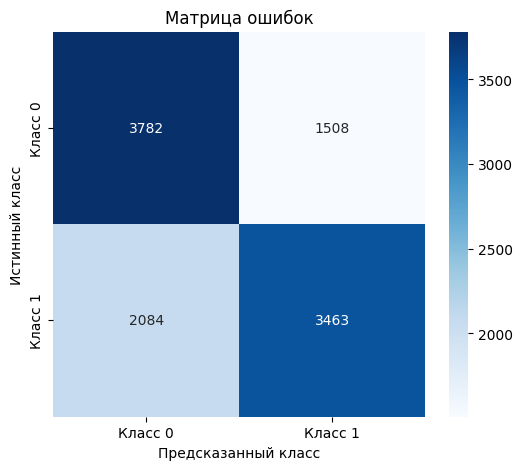

In [114]:
cm = confusion_matrix(y_test, cat_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Класс 0', 'Класс 1'], 
            yticklabels=['Класс 0', 'Класс 1'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

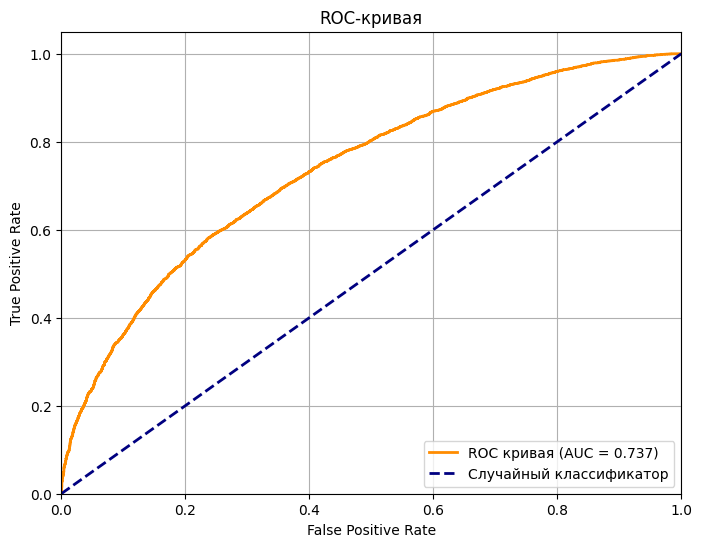

In [115]:
fpr, tpr, thresholds = roc_curve(y_test, cat_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

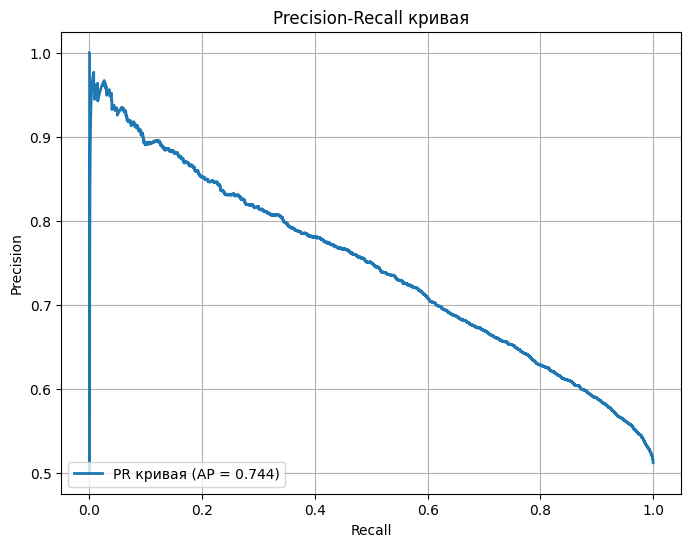

In [116]:
precision, recall, _ = precision_recall_curve(y_test, cat_probs)
avg_precision = average_precision_score(y_test, cat_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, lw=2, label=f'PR кривая (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [117]:
feature_importance = pd.DataFrame(catboost_model.get_feature_importance(), 
                                  index=[*X.columns],
                                  columns=['feature_importance']).sort_values('feature_importance',
                                                                              ascending=False)
feature_importance

,feature_importance
county_city_location,16.150576
collision_hour,14.226806
vehicle_age,9.881664
collision_month,9.407467
vehicle_type,8.399922
distance,7.757652
direction,7.099343
vehicle_transmission,5.276765
lighting,5.023603
location_type,4.694282


Одним из важных факторов влияющих на аварийность является освещенность lighting.
- Построим Гистограмму по данному признаку с разделение на at_fault
- Предложение: установить датчик освещенности дороги, и автоматизировать включение фар (дальнего и ближнего света) в зависимости от освещенности и встречного потока автомобилей. Также в случае недостаточно освещенности предупредить водителя об этом, либо ограничить максимальную скорость автомобиля

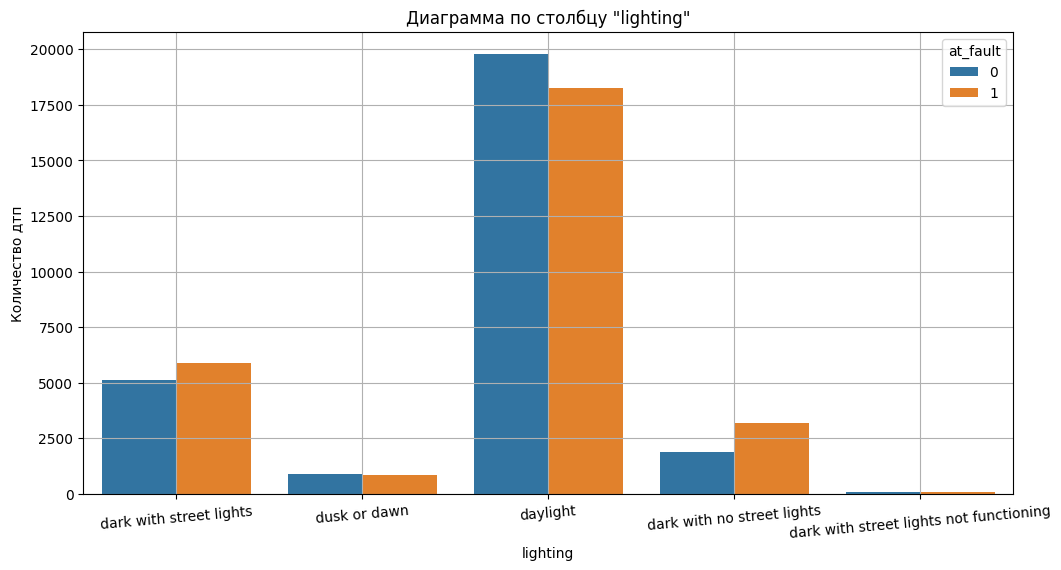

In [118]:
df[['lighting','at_fault']]
sns.countplot(data=df[['lighting','at_fault']], x='lighting', hue='at_fault')
plt.grid(True)
plt.ylabel('Количество дтп')
plt.xlabel('lighting')
plt.xticks(rotation=5)
plt.title(f'Диаграмма по столбцу "lighting"')
plt.show();


### Промежуточный вывод
Исходя из диаграммы становится видно, что больше аварий происходило при свете дня. Но также имеются и в темное время суток с освещением и без. Поэтому предложение по датчикам не самое рациональное, но при низкой себестоимости датчика, данное предложение сможет помочь снизить аварийность.

## Выводы
- Кратко опишите лучшую модель.
- Сделайте вывод: насколько возможно создание адекватной системы оценки риска при выдаче авто?
- Какие факторы ещё необходимо собирать, чтобы улучшить модель?

По итогу тестирования моделей наилучший результат показала модель Catboost с метриками f1: 0.645 и ROC-AUC: 0.665. Для получения гиперпараметров был использован перебор через Optuna.

Создание адекватной системы оценки риска при выдаче авто возможно, но при условии учета онлайн факторов: состояния водителя, трезвость и т.д. Но все же в данном случае сильно влияние детерминированного хаоса, так как участник движения не один единственный.

Чтобы улучшить модель можно собирать данные о:
- стаже вождения
- предыдущих нарушениях пдд и авариях